# Exploratory Data Analysis & Integrity

**Purpose:** Document dataset acquisition, schema verification, and clinical context.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

# Add project root to path
sys.path.append(os.path.abspath('..'))
from src.preprocessing import load_and_split_data

import warnings
warnings.filterwarnings('ignore')

### 1. Dataset Overview & Acquisition

We load the dataset using our reusable pipeline from `src.preprocessing` (which internally handles data downloading via `ucimlrepo` if the raw file doesn't exist).

In [2]:
filepath = os.path.join("..", "data", "raw", "heart_disease_uci.csv")
X_train, X_test, y_train, y_test = load_and_split_data(filepath)

print(f"Training Set Size: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test Set Size: {X_test.shape[0]} rows, {X_test.shape[1]} features")

Training Set Size: 242 rows, 13 features
Test Set Size: 61 rows, 13 features


### 2. Clinical Feature Dictionary

Features include:
- **age**: age in years
- **sex**: 1 = male, 0 = female
- **cp**: chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)
- **trestbps**: resting blood pressure (mm Hg)
- **chol**: serum cholesterol (mg/dl)
- **fbs**: fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
- **restecg**: resting electrocardiographic results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)
- **thalach**: maximum heart rate achieved
- **exang**: exercise induced angina (1 = yes, 0 = no)
- **oldpeak**: ST depression induced by exercise relative to rest
- **slope**: the slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)
- **ca**: number of major vessels (0-3) colored by flourosopy
- **thal**: 3 = normal; 6 = fixed defect; 7 = reversable defect

### 3. Missing Values & Target Binarization

In [3]:
# Look at the raw data to see missing values
raw_df = pd.read_csv(filepath)
print("Missing Values in raw dataset:")
print(raw_df.isna().sum()[raw_df.isna().sum() > 0])

Missing Values in raw dataset:
ca      4
thal    2
dtype: int64


We observed missing values in `ca` (4) and `thal` (2). Our preprocessing pipeline strictly imputes these using median/mode *after* splitting the data.

**Target Binarization Rationale:** The original target `num` ranges from 0 to 4. We binarized it where `0` means No Disease and `1-4` means Disease Present, aligning with standard binary classification tasks for this dataset.

In [4]:
print("Original target 'num' distribution:")
print(raw_df['num'].value_counts())
print("\nBinarized target 'y_train' distribution:")
print(y_train.value_counts())

Original target 'num' distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binarized target 'y_train' distribution:
target
0    131
1    111
Name: count, dtype: int64


### 4. Univariate and Bivariate Distributions

Let's visualize distributions on the training data.

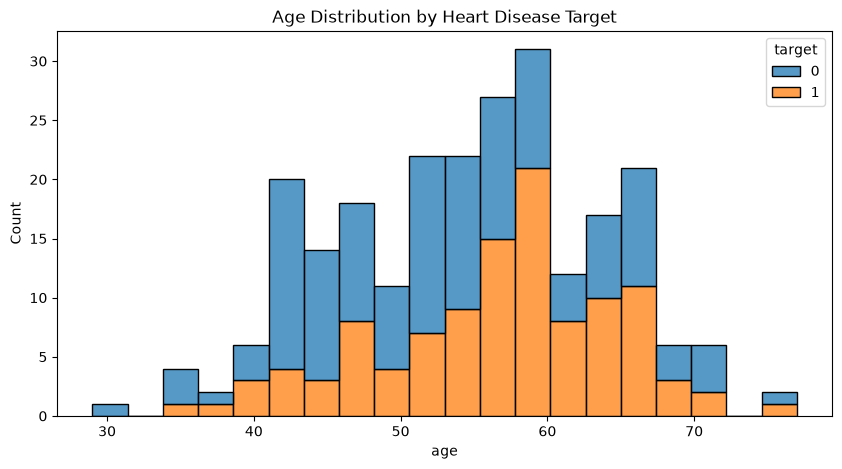

In [5]:
# Combine X_train and y_train for EDA
eda_df = X_train.copy()
eda_df['target'] = y_train

plt.figure(figsize=(10, 5))
sns.histplot(data=eda_df, x='age', hue='target', multiple='stack', bins=20)
plt.title("Age Distribution by Heart Disease Target")
plt.show()

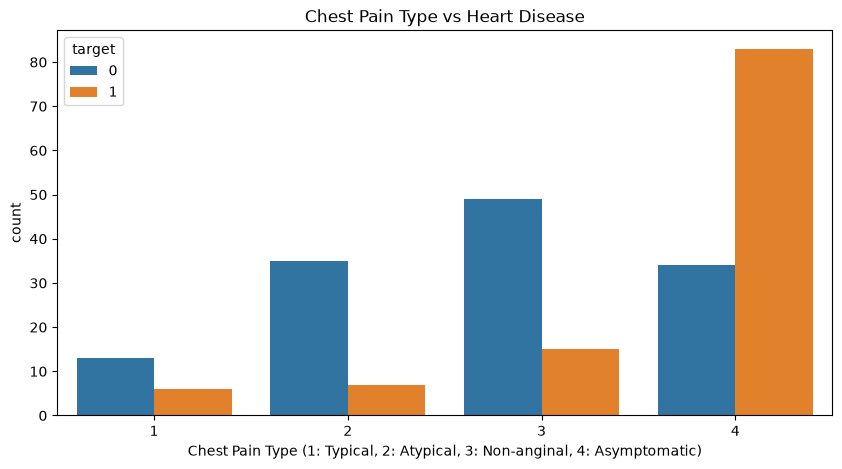

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(data=eda_df, x='cp', hue='target')
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type (1: Typical, 2: Atypical, 3: Non-anginal, 4: Asymptomatic)")
plt.show()

### 5. Correlation Analysis

Using Spearman correlation to capture non-linear relationships without relying on imputation logic (we just dropna for visualization).

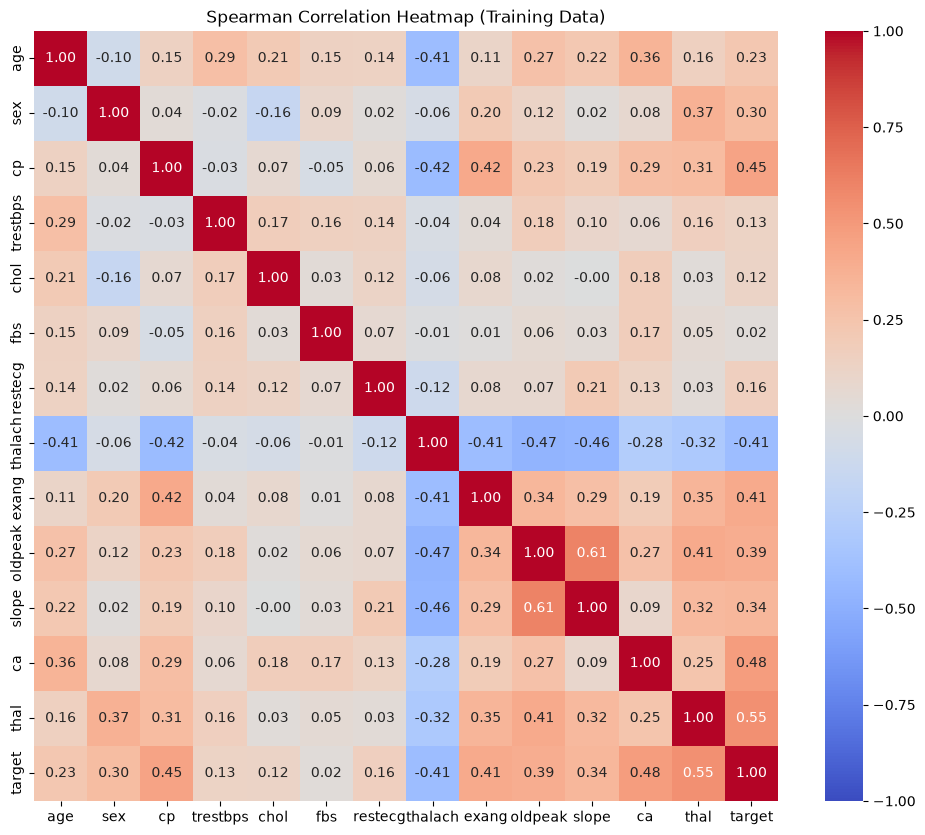

In [7]:
plt.figure(figsize=(12, 10))
corr = eda_df.dropna().corr(method='spearman')
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap (Training Data)")
plt.show()